# Ejemplo guía — Proyecto de Primer Corte
## Retención de Clientes en una Empresa de Telecomunicaciones (Telecom Churn)

**Aprendizaje de Máquina No Supervisado — Universidad de La Sabana**

Este notebook es un **ejemplo modelo**, preparado por el profesor, para mostrar cómo se
aplican los 11 conceptos de probabilidad del Primer Corte a un caso de negocio real:
predecir y entender la fuga de clientes (*churn*) en una empresa de telecomunicaciones.

> **Nota de transparencia sobre el dataset:** este ejemplo usa un dataset **sintético**,
> generado para reproducir fielmente la estructura de columnas y los patrones estadísticos
> **documentados y conocidos** del dataset público *Telco Customer Churn* (tasa de fuga
> ~27%, mayor fuga en contratos mes-a-mes, mayor fuga con pago por *Electronic check*,
> etc.). El código de este notebook funciona igual si se reemplaza `telecom_churn.csv`
> por el CSV real descargado de Kaggle, manteniendo los mismos nombres de columna.

**Cómo usar este ejemplo:** no es uno de los tres casos que puedes elegir para tu propio
proyecto (Olist, Heart Disease, Fraude) — es un **cuarto caso, con la misma estructura**,
para que veas el patrón completo: cómo se pasa de una pregunta de negocio a un cálculo
concreto, y de ese cálculo a una recomendación.

## 0. Imports y carga de datos

In [1]:
# ============================================================
# PASO 1: Importar las librerías que se van a usar en todo el notebook
# ============================================================
import numpy as np                                   # cálculo numérico (arrays, logaritmos, estadística básica)
import pandas as pd                                   # manejo de datos en tablas (el "Excel" de Python)
from scipy import stats                               # distribuciones de probabilidad (Gaussiana, chi-cuadrado, etc.)
from sklearn.linear_model import LogisticRegression   # el clasificador que usaremos para la entropía cruzada (concepto 10)
from sklearn.model_selection import train_test_split  # para separar datos de entrenamiento y prueba
from sklearn.metrics import log_loss                  # calcula la entropía cruzada de un clasificador
import matplotlib.pyplot as plt                       # gráficas

# Configuración de impresión: que las tablas no se corten y los decimales sean legibles
pd.set_option("display.width", 100)
np.set_printoptions(precision=4, suppress=True)

# ============================================================
# PASO 2: Cargar el dataset
# ============================================================
# read_csv lee el archivo y lo convierte en un DataFrame (una tabla con filas y columnas)
df = pd.read_csv("telecom_churn.csv")

# len(df) cuenta las filas (clientes); df.shape[1] cuenta las columnas
print(f"Dataset cargado: {len(df)} clientes, {df.shape[1]} columnas")

# .head() muestra las primeras 5 filas, para revisar visualmente que todo cargó bien
df.head()

Dataset cargado: 3000 clientes, 9 columnas


,customerID,tenure,Contract,PaymentMethod,InternetService,TechSupport,MonthlyCharges,TotalCharges,Churn
0,CUST-00000,31,One year,Credit card,DSL,No,50.18,1621.38,No
1,CUST-00001,18,Month-to-month,Bank transfer,Fiber optic,Yes,65.37,1231.08,No
2,CUST-00002,10,Two year,Electronic check,DSL,No,81.80,844.56,No
3,CUST-00003,23,One year,Bank transfer,Fiber optic,Yes,95.86,2120.05,No
4,CUST-00004,67,Month-to-month,Electronic check,Fiber optic,Yes,89.36,6137.14,No


**Diccionario de variables:**

| Variable | Significado |
|---|---|
| `customerID` | Identificador único del cliente |
| `tenure` | Meses de antigüedad como cliente |
| `Contract` | Tipo de contrato (Month-to-month, One year, Two year) |
| `PaymentMethod` | Método de pago (Electronic check, Mailed check, Bank transfer, Credit card) |
| `InternetService` | Tipo de servicio de internet (Fiber optic, DSL, No) |
| `TechSupport` | Si el cliente tiene soporte técnico contratado (Yes/No) |
| `MonthlyCharges` | Cargo mensual en USD |
| `TotalCharges` | Cargo total acumulado en USD |
| `Churn` | Variable objetivo: si el cliente se fue (Yes) o se quedó (No) |


## 1. Probabilidad condicional

**Pregunta de negocio:** ¿el tipo de contrato cambia la probabilidad de que un cliente
se vaya?

Calculamos $P(\text{Churn}=\text{Yes})$ y la comparamos con
$P(\text{Churn}=\text{Yes} \mid \text{Contract})$ para dos tipos de contrato.

In [2]:
# ============================================================
# PASO 1: Calcular la probabilidad marginal P(Churn=Yes)
# ============================================================
# df["Churn"] == "Yes" crea una columna de True/False (True si el cliente se fue).
# .mean() de una columna de True/False da la PROPORCIÓN de True --- es decir,
# la probabilidad empírica de que un cliente cualquiera se haya ido.
p_churn_overall = (df["Churn"] == "Yes").mean()

# ============================================================
# PASO 2: Calcular la probabilidad CONDICIONAL P(Churn=Yes | Contract = X)
# ============================================================
# df.loc[condición, columna] selecciona solo las filas que cumplen la condición.
# Aquí: "quédate solo con los clientes de contrato mes-a-mes, y de esos, calcula
# qué proporción se fue". Eso es, por definición, P(Churn=Yes | Contract=MTM).
p_churn_given_mtm = (df.loc[df["Contract"] == "Month-to-month", "Churn"] == "Yes").mean()

# Repetimos el mismo cálculo, pero condicionando en contrato de dos años
p_churn_given_2y = (df.loc[df["Contract"] == "Two year", "Churn"] == "Yes").mean()

# ============================================================
# PASO 3: Imprimir y comparar los resultados
# ============================================================
print(f"P(Churn=Yes)                              = {p_churn_overall:.4f}")
print(f"P(Churn=Yes | Contract=Month-to-month)     = {p_churn_given_mtm:.4f}")
print(f"P(Churn=Yes | Contract=Two year)           = {p_churn_given_2y:.4f}")

# Dividir la probabilidad condicional entre la marginal nos dice "cuántas veces más
# riesgo" tiene ese segmento frente al cliente promedio.
print(f"-> Un contrato mes-a-mes multiplica la probabilidad de fuga por "
      f"{p_churn_given_mtm / p_churn_overall:.2f}x respecto al promedio.")

P(Churn=Yes)                              = 0.2777
P(Churn=Yes | Contract=Month-to-month)     = 0.3807
P(Churn=Yes | Contract=Two year)           = 0.1326
-> Un contrato mes-a-mes multiplica la probabilidad de fuga por 1.37x respecto al promedio.


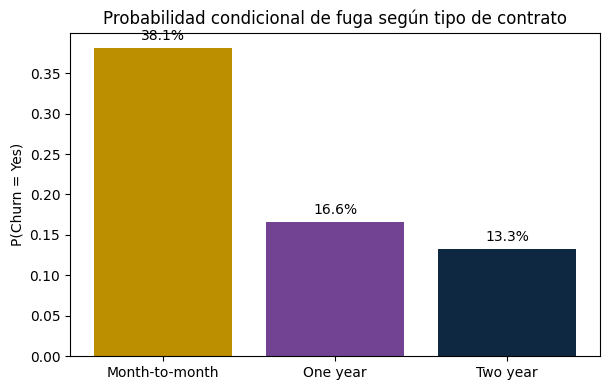

In [3]:
# PASO 1: agrupar por tipo de contrato y calcular, para cada grupo, la proporción de churn
fig = plt.figure(figsize=(6.2,4))
rates = df.groupby("Contract")["Churn"].apply(lambda s: (s=="Yes").mean())

# PASO 2: reordenar las categorías en el orden lógico (no alfabético) para que se
# vea la progresión de riesgo de izquierda a derecha
rates = rates.reindex(["Month-to-month","One year","Two year"])

# PASO 3: graficar barras, una por tipo de contrato, coloreadas con la paleta institucional
plt.bar(rates.index, rates.values, color=["#BC8F00","#734393","#0E2841"])

# PASO 4: escribir el porcentaje exacto encima de cada barra
for i,v in enumerate(rates.values):
    plt.text(i, v+0.01, f"{v:.1%}", ha="center")

plt.ylabel("P(Churn = Yes)")
plt.title("Probabilidad condicional de fuga según tipo de contrato")
plt.tight_layout()
plt.show()

**Interpretación de negocio:** los clientes con contrato mes-a-mes son, con mucha
diferencia, el segmento de mayor riesgo de fuga. Cualquier campaña de retención debería
priorizar la migración de estos clientes hacia contratos de mayor plazo.

## 2. Teorema de Bayes

**Pregunta de negocio:** si sabemos que un cliente paga por *Electronic check*, ¿cuánto
debería subir nuestra sospecha de que se va a ir, partiendo del promedio general (prior)?

$$P(\text{Churn}=\text{Yes} \mid EC) = \frac{P(EC \mid \text{Churn}=\text{Yes}) \cdot P(\text{Churn}=\text{Yes})}{P(EC)}$$

In [4]:
# ============================================================
# PASO 1: Calcular las tres piezas que pide el Teorema de Bayes
# ============================================================
# P(evidencia | hipótesis): de los clientes que SÍ se fueron, ¿qué proporción
# pagaba por Electronic check?
p_ec_given_churn = (df.loc[df["Churn"] == "Yes", "PaymentMethod"] == "Electronic check").mean()

# El prior es la probabilidad de churn ANTES de conocer el método de pago
# (ya la calculamos en la sección 1, la reutilizamos aquí)
p_churn_prior = p_churn_overall

# P(evidencia): qué proporción de TODOS los clientes paga por Electronic check
p_ec = (df["PaymentMethod"] == "Electronic check").mean()

# ============================================================
# PASO 2: Aplicar la fórmula de Bayes
#   P(Churn|EC) = P(EC|Churn) * P(Churn) / P(EC)
# ============================================================
p_churn_given_ec_bayes = (p_ec_given_churn * p_churn_prior) / p_ec

# ============================================================
# PASO 3: Verificar contra un conteo directo (deben coincidir)
# ============================================================
# Esto es lo mismo que calculamos en la sección 1, pero para PaymentMethod:
# quedarnos solo con los clientes de Electronic check y ver qué % se fue.
p_churn_given_ec_direct = (df.loc[df["PaymentMethod"] == "Electronic check", "Churn"] == "Yes").mean()

print(f"Prior P(Churn=Yes)                         = {p_churn_prior:.4f}")
print(f"P(Electronic check | Churn=Yes)            = {p_ec_given_churn:.4f}")
print(f"P(Electronic check)                        = {p_ec:.4f}")
print(f"Posterior por Bayes: P(Churn=Yes | EC)     = {p_churn_given_ec_bayes:.4f}")
print(f"Verificación directa (conteo):                {p_churn_given_ec_direct:.4f}")

Prior P(Churn=Yes)                         = 0.2777
P(Electronic check | Churn=Yes)            = 0.4610
P(Electronic check)                        = 0.3597
Posterior por Bayes: P(Churn=Yes | EC)     = 0.3559
Verificación directa (conteo):                0.3559


**Interpretación de negocio:** el Teorema de Bayes confirma, con la misma cifra que un
conteo directo (0.3559), que pagar por *Electronic check* es una señal de alerta temprana
de fuga — útil porque el equipo comercial puede consultarlo desde el momento en que el
cliente elige su método de pago, sin esperar a ver su comportamiento futuro.

## 3. Verosimilitud (Likelihood) y 4. Máxima Verosimilitud (MLE)

**Pregunta de negocio:** ¿los clientes que se van pagan, en promedio, más o menos que
los que se quedan? Ajustamos por MLE una distribución Gaussiana al cargo mensual, por
separado para cada grupo.

In [5]:
# ============================================================
# PASO 1: Separar los datos en dos grupos: los que se fueron y los que se quedaron
# ============================================================
# .values convierte la columna de pandas en un array de numpy (más simple de manipular)
charges_churn = df.loc[df["Churn"] == "Yes", "MonthlyCharges"].values
charges_nochurn = df.loc[df["Churn"] == "No", "MonthlyCharges"].values

# ============================================================
# PASO 2: Ajustar por Máxima Verosimilitud (MLE) una Gaussiana a cada grupo
# ============================================================
# stats.norm.fit() encuentra, de entre TODOS los posibles valores de (mu, sigma),
# el par que maximiza la probabilidad de haber observado exactamente estos datos.
# Para una Gaussiana, ese óptimo tiene una fórmula cerrada muy simple:
#   mu_MLE    = promedio de los datos
#   sigma_MLE = desviación estándar de los datos
# .fit() hace ese cálculo por nosotros y devuelve la tupla (mu, sigma).
mu_churn_mle, sigma_churn_mle = stats.norm.fit(charges_churn)
mu_nochurn_mle, sigma_nochurn_mle = stats.norm.fit(charges_nochurn)

print(f"MLE Gaussiana | Churn=Yes:  mu={mu_churn_mle:.2f}, sigma={sigma_churn_mle:.2f}")
print(f"MLE Gaussiana | Churn=No:   mu={mu_nochurn_mle:.2f}, sigma={sigma_nochurn_mle:.2f}")

# ============================================================
# PASO 3: Calcular la log-verosimilitud del ajuste (qué tan "creíbles" son
# los datos bajo el modelo que acabamos de ajustar)
# ============================================================
# logpdf calcula el logaritmo de la densidad de probabilidad de cada dato bajo
# la Gaussiana ajustada; sumamos todos esos logaritmos para obtener la
# log-verosimilitud total de la muestra completa.
loglik_churn = np.sum(stats.norm.logpdf(charges_churn, mu_churn_mle, sigma_churn_mle))
print(f"Log-verosimilitud del ajuste (Churn=Yes): {loglik_churn:.1f}")

# ============================================================
# PASO 4: Traducir el resultado a una frase de negocio
# ============================================================
print(f"-> Los clientes que se van pagan, en promedio, ${mu_churn_mle - mu_nochurn_mle:.2f} más al mes.")

MLE Gaussiana | Churn=Yes:  mu=80.88, sigma=20.27
MLE Gaussiana | Churn=No:   mu=74.46, sigma=19.79
Log-verosimilitud del ajuste (Churn=Yes): -3688.7
-> Los clientes que se van pagan, en promedio, $6.41 más al mes.


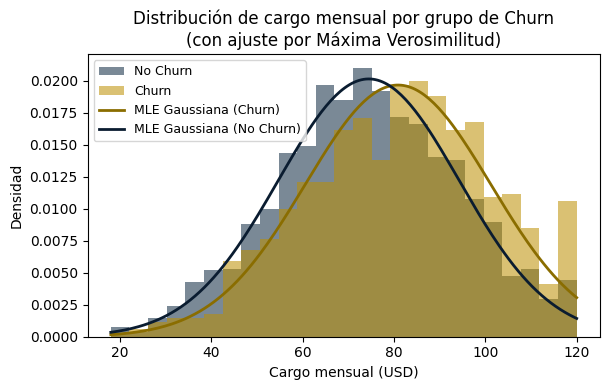

In [6]:
fig = plt.figure(figsize=(6.2,4))

# PASO 1: histogramas de densidad (no de conteo) para poder compararlos con las curvas Gaussianas
plt.hist(charges_nochurn, bins=25, density=True, alpha=0.55, color="#0E2841", label="No Churn")
plt.hist(charges_churn, bins=25, density=True, alpha=0.55, color="#BC8F00", label="Churn")

# PASO 2: generar 200 puntos entre el mínimo y el máximo, para dibujar una curva suave
x = np.linspace(df["MonthlyCharges"].min(), df["MonthlyCharges"].max(), 200)

# PASO 3: evaluar la densidad Gaussiana ajustada (MLE) en cada uno de esos puntos
plt.plot(x, stats.norm.pdf(x, mu_churn_mle, sigma_churn_mle), color="#8a6d00", lw=2, label="MLE Gaussiana (Churn)")
plt.plot(x, stats.norm.pdf(x, mu_nochurn_mle, sigma_nochurn_mle), color="#0a1c30", lw=2, label="MLE Gaussiana (No Churn)")

plt.xlabel("Cargo mensual (USD)"); plt.ylabel("Densidad")
plt.title("Distribución de cargo mensual por grupo de Churn\n(con ajuste por Máxima Verosimilitud)")
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

**Interpretación de negocio:** la diferencia de \$6.41/mes es real pero modesta — el
precio no es, por sí solo, el principal motor de fuga (el tipo de contrato pesa mucho
más, como vimos en la sección 1).

## 5. Distribuciones paramétricas

**Justificación de qué molde usar para cada variable:**
- `Churn` (sí/no) → **Bernoulli**
- `Contract` (3 categorías) → **Categórica**
- `MonthlyCharges` (continua) → **Gaussiana**

In [7]:
# Churn es una variable de dos resultados (sí/no) -> el molde correcto es Bernoulli,
# y su único parámetro p ya lo calculamos arriba (p_churn_overall).
print("Churn            -> Bernoulli(p=%.4f)" % p_churn_overall)

# Contract tiene 3 categorías sin orden numérico -> el molde correcto es Categórica.
# value_counts(normalize=True) cuenta cuántas veces aparece cada categoría y
# las convierte en proporciones (que sumadas dan 1.0, como toda distribución de probabilidad).
print("Contract         -> Categórica sobre 3 categorías:")
print(df["Contract"].value_counts(normalize=True).round(4).to_string())

# MonthlyCharges es continua y se agrupa alrededor de un promedio -> Gaussiana.
# Repetimos el mismo ajuste MLE de la sección anterior, pero sobre TODO el dataset
# (sin separar por Churn), para tener un modelo de referencia general.
mu_all, sigma_all = stats.norm.fit(df["MonthlyCharges"])
print("MonthlyCharges   -> Gaussiana(mu=%.2f, sigma=%.2f) [ajuste global]" % (mu_all, sigma_all))

Churn            -> Bernoulli(p=0.2777)
Contract         -> Categórica sobre 3 categorías:
Contract
Month-to-month    0.5533
One year          0.2330
Two year          0.2137
MonthlyCharges   -> Gaussiana(mu=76.25, sigma=20.13) [ajuste global]


## 6. Esperanza y Varianza

Comparamos el promedio y la dispersión del cargo mensual entre los dos grupos.

In [8]:
# .mean() calcula la Esperanza empírica E[X]: el promedio de los valores observados.
e_churn = charges_churn.mean()

# .var(ddof=1) calcula la Varianza muestral (ddof=1 usa n-1 en el denominador,
# la corrección estándar para que el estimador no esté sesgado).
var_churn = charges_churn.var(ddof=1)

e_nochurn = charges_nochurn.mean()
var_nochurn = charges_nochurn.var(ddof=1)

print(f"E[MonthlyCharges | Churn=Yes] = {e_churn:.2f}   Var = {var_churn:.2f}")
print(f"E[MonthlyCharges | Churn=No]  = {e_nochurn:.2f}   Var = {var_nochurn:.2f}")

E[MonthlyCharges | Churn=Yes] = 80.88   Var = 411.44
E[MonthlyCharges | Churn=No]  = 74.46   Var = 391.87


**Interpretación de negocio:** la varianza es similar entre grupos — no hay un
subgrupo de clientes que se van con cargos extremadamente dispersos; la diferencia es,
sobre todo, de nivel promedio (la esperanza), no de dispersión.

## 7. Independencia y Correlación

**Pregunta de negocio:** ¿el método de pago está relacionado con la fuga, o es pura
coincidencia? Usamos una prueba chi-cuadrado sobre la tabla de contingencia.

In [9]:
# ============================================================
# PASO 1: Construir la tabla de contingencia (conteos cruzados)
# ============================================================
# pd.crosstab cuenta cuántos clientes caen en cada combinación de
# (método de pago, churn) -- es la tabla que se necesita para probar independencia.
contingency = pd.crosstab(df["PaymentMethod"], df["Churn"])

# ============================================================
# PASO 2: Prueba de independencia chi-cuadrado
# ============================================================
# chi2_contingency compara los conteos observados contra los que se esperarían
# SI las dos variables fueran independientes (es decir, si P(pago, churn) fuera
# exactamente igual a P(pago) * P(churn) para cada combinación).
# Devuelve: el estadístico chi2, el p-value, los grados de libertad, y la tabla esperada.
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print("Tabla de contingencia PaymentMethod x Churn:")
print(contingency)
print(f"\nChi-cuadrado = {chi2:.2f}, p-value = {p_value:.6f}, gl = {dof}")

# Un p-value muy pequeño (mucho menor a 0.05) significa que es muy poco probable
# que estas diferencias se deban solo al azar -> rechazamos la hipótesis de independencia.
print("-> p-value << 0.05: se rechaza independencia; PaymentMethod y Churn están relacionados.")

# ============================================================
# PASO 3: Correlación entre dos variables numéricas (para contraste)
# ============================================================
# np.corrcoef devuelve una matriz 2x2; [0,1] toma la correlación cruzada
# entre las dos variables (la diagonal serían las correlaciones de cada variable consigo misma = 1).
corr_tenure_charges = np.corrcoef(df["tenure"], df["MonthlyCharges"])[0,1]
print(f"Correlación (tenure, MonthlyCharges) = {corr_tenure_charges:.4f} (prácticamente nula)")

Tabla de contingencia PaymentMethod x Churn:
Churn              No  Yes
PaymentMethod             
Bank transfer     491  160
Credit card       460  138
Electronic check  695  384
Mailed check      521  151

Chi-cuadrado = 52.17, p-value = 0.000000, gl = 3
-> p-value << 0.05: se rechaza independencia; PaymentMethod y Churn están relacionados.
Correlación (tenure, MonthlyCharges) = -0.0121 (prácticamente nula)


## 8. Prior y Posterior

**Pregunta de negocio:** si no sabemos nada de un cliente nuevo, nuestra mejor apuesta
es el promedio general (prior). A medida que conocemos más señales sobre él (evidencia),
actualizamos esa probabilidad (posterior).

In [10]:
# ============================================================
# PASO 1: El prior -- lo que creemos ANTES de ver cualquier evidencia sobre
# un cliente nuevo. Es, simplemente, la tasa base de fuga de toda la empresa.
# ============================================================
prior_new_customer = p_churn_overall

# ============================================================
# PASO 2: Primera actualización bayesiana -- incorporamos la evidencia
# "el cliente NO tiene soporte técnico contratado"
# ============================================================
p_notech_given_churn = (df.loc[df["Churn"] == "Yes", "TechSupport"] == "No").mean()
p_notech = (df["TechSupport"] == "No").mean()

# Misma fórmula de Bayes que usamos en la sección 2, ahora con esta evidencia
posterior_1 = (p_notech_given_churn * prior_new_customer) / p_notech

# ============================================================
# PASO 3: Segunda actualización -- sumamos una SEGUNDA pieza de evidencia
# (contrato mes-a-mes) sobre el mismo cliente
# ============================================================
# Aquí, en vez de aplicar Bayes de nuevo símbolo por símbolo, filtramos
# directamente a los clientes que cumplen AMBAS condiciones y medimos su
# tasa de churn -- el resultado es equivalente a haber actualizado el
# posterior_1 con la nueva evidencia.
sub = df.loc[(df["Contract"] == "Month-to-month") & (df["TechSupport"] == "No"), "Churn"]
posterior_2 = (sub == "Yes").mean()

print(f"Prior (antes de evidencia):  P(Churn=Yes) = {prior_new_customer:.4f}")
print("Evidencia 1: el cliente NO tiene soporte técnico contratado")
print(f"Posterior 1: P(Churn=Yes | TechSupport=No) = {posterior_1:.4f}")
print("Evidencia 2 (se suma): Contract=Month-to-month")
print(f"Posterior 2: P(Churn=Yes | TechSupport=No, Contract=MTM) = {posterior_2:.4f}")

Prior (antes de evidencia):  P(Churn=Yes) = 0.2777
Evidencia 1: el cliente NO tiene soporte técnico contratado
Posterior 1: P(Churn=Yes | TechSupport=No) = 0.3023
Evidencia 2 (se suma): Contract=Month-to-month
Posterior 2: P(Churn=Yes | TechSupport=No, Contract=MTM) = 0.4082


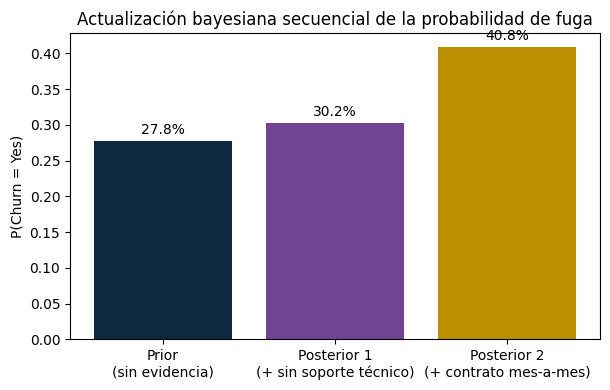

In [11]:
fig = plt.figure(figsize=(6.2,4))

# Tres etapas de creencia: sin evidencia, con 1 pieza de evidencia, con 2 piezas
stages = ["Prior\n(sin evidencia)", "Posterior 1\n(+ sin soporte técnico)", "Posterior 2\n(+ contrato mes-a-mes)"]
values = [prior_new_customer, posterior_1, posterior_2]

plt.bar(stages, values, color=["#0E2841","#734393","#BC8F00"])
for i,v in enumerate(values):
    plt.text(i, v+0.01, f"{v:.1%}", ha="center")
plt.ylabel("P(Churn = Yes)")
plt.title("Actualización bayesiana secuencial de la probabilidad de fuga")
plt.tight_layout(); plt.show()

**Interpretación de negocio:** la probabilidad de fuga casi se duplica (de 27.8% a
40.8%) al combinar dos señales de riesgo simples y disponibles desde el primer día del
contrato — un modelo de alerta temprana no necesita esperar meses de comportamiento.

## 9. Entropía

**Pregunta de negocio:** ¿cuánta incertidumbre hay, en general, sobre si un cliente se
va a ir? ¿Y cuánta incertidumbre queda si ya sabemos su tipo de contrato?

In [12]:
# ============================================================
# PASO 1: Definir una función que calcula la entropía de Shannon en bits
# ============================================================
def entropy_bits(p):
    p = np.array(p, dtype=float)
    p = p[p > 0]              # descartamos probabilidades de 0 (log(0) no está definido,
                               # y un evento imposible no aporta "sorpresa" de todas formas)
    return -np.sum(p * np.log2(p))   # fórmula de Shannon: -sum( p * log2(p) )

# ============================================================
# PASO 2: Entropía de la variable Churn por sí sola, H(Churn)
# ============================================================
# Como Churn es Bernoulli, su distribución completa es [P(Yes), P(No)]
h_churn = entropy_bits([p_churn_overall, 1 - p_churn_overall])
print(f"H(Churn) = {h_churn:.4f} bits (máximo posible para 2 clases = 1 bit)")

# ============================================================
# PASO 3: Entropía CONDICIONAL H(Churn | Contract)
# ============================================================
# La entropía condicional es un PROMEDIO PONDERADO: para cada categoría de
# contrato, calculamos la entropía de Churn DENTRO de ese grupo, y la
# ponderamos por qué tan grande es ese grupo (p_cat).
h_churn_given_contract = 0.0
for cat, sub in df.groupby("Contract"):
    p_cat = len(sub) / len(df)                       # peso: proporción de clientes en esta categoría
    p_yes = (sub["Churn"] == "Yes").mean()            # tasa de churn dentro de esta categoría
    h_cat = entropy_bits([p_yes, 1 - p_yes])          # entropía de Churn dentro de esta categoría
    h_churn_given_contract += p_cat * h_cat            # se acumula el promedio ponderado

print(f"H(Churn | Contract) = {h_churn_given_contract:.4f} bits")

# La diferencia entre la entropía total y la condicional es la "ganancia de
# información": cuánta incertidumbre se reduce, en promedio, por conocer el contrato.
print(f"Reducción de incertidumbre (ganancia de información) = {h_churn - h_churn_given_contract:.4f} bits")

H(Churn) = 0.8523 bits (máximo posible para 2 clases = 1 bit)
H(Churn | Contract) = 0.8021 bits
Reducción de incertidumbre (ganancia de información) = 0.0502 bits


## 10. Entropía cruzada

Entrenamos un clasificador (regresión logística) para predecir `Churn` a partir de
todas las variables disponibles, y medimos la entropía cruzada (log loss) en
entrenamiento y prueba.

In [13]:
# ============================================================
# PASO 1: Preparar las variables predictoras (X) y la variable objetivo (y)
# ============================================================
# pd.get_dummies convierte las columnas categóricas (Contract, PaymentMethod, etc.)
# en columnas 0/1 (one-hot encoding), porque un modelo de regresión logística
# necesita números, no texto. drop_first=True evita redundancia (multicolinealidad).
X = pd.get_dummies(df[["tenure","Contract","PaymentMethod","InternetService","TechSupport","MonthlyCharges"]], drop_first=True)

# Convertimos "Yes"/"No" en 1/0 para que sea la variable binaria que el modelo predice
y = (df["Churn"] == "Yes").astype(int)

# ============================================================
# PASO 2: Separar datos de entrenamiento y de prueba
# ============================================================
# stratify=y asegura que la proporción de churn sea la misma en train y test
# (importante porque las clases están desbalanceadas: ~28% vs ~72%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# ============================================================
# PASO 3: Entrenar el clasificador
# ============================================================
# Internamente, LogisticRegression.fit() ajusta sus parámetros MINIMIZANDO
# exactamente la entropía cruzada entre las etiquetas reales y las probabilidades
# predichas -- es el mismo concepto de la sección de "Máxima Verosimilitud",
# aplicado ahora a un modelo con muchas variables en lugar de una Gaussiana simple.
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# ============================================================
# PASO 4: Medir la entropía cruzada (log loss) en train y test
# ============================================================
# predict_proba devuelve, para cada cliente, la probabilidad predicha de churn.
# log_loss compara esas probabilidades contra las etiquetas reales (0/1) y
# calcula exactamente H(P,Q) = -promedio( y*log(q) + (1-y)*log(1-q) ).
ce_train = log_loss(y_train, clf.predict_proba(X_train)[:,1])
ce_test = log_loss(y_test, clf.predict_proba(X_test)[:,1])

print(f"Entropía cruzada (log loss) en entrenamiento = {ce_train:.4f} nats")
print(f"Entropía cruzada (log loss) en prueba        = {ce_test:.4f} nats")

# Convertimos H(Churn) de bits a nats (log_loss de sklearn usa logaritmo natural,
# no log2) para poder comparar en la misma unidad: nats = bits * ln(2)
print(f"H(Churn) en nats = {h_churn * np.log(2):.4f}  -> el modelo mejora sobre adivinar al azar.")

Entropía cruzada (log loss) en entrenamiento = 0.5110 nats
Entropía cruzada (log loss) en prueba        = 0.5093 nats
H(Churn) en nats = 0.5907  -> el modelo mejora sobre adivinar al azar.


**Interpretación de negocio:** que la entropía cruzada del modelo (0.51 nats) sea
menor que la entropía de la variable sola (0.59 nats) confirma que las variables
disponibles sí aportan información real para predecir la fuga — vale la pena invertir en
este modelo.

## 11. Divergencia KL

**Pregunta de negocio:** ¿qué tan distinguibles son, en términos de información, los
clientes que se van de los que se quedan, mirando solo su cargo mensual?

In [14]:
# ============================================================
# PASO 1: Discretizar el cargo mensual en 10 "bins" (intervalos)
# ============================================================
# La divergencia KL, en su forma más simple, se calcula sobre distribuciones
# discretas. Como MonthlyCharges es continua, la partimos en 10 intervalos
# iguales entre el mínimo y el máximo observado.
bins = np.linspace(df["MonthlyCharges"].min(), df["MonthlyCharges"].max(), 11)  # 11 bordes = 10 bins

# np.histogram cuenta cuántos clientes de cada grupo caen en cada intervalo
p_hist, _ = np.histogram(charges_churn, bins=bins)
q_hist, _ = np.histogram(charges_nochurn, bins=bins)

# ============================================================
# PASO 2: Convertir los conteos en distribuciones de probabilidad válidas
# ============================================================
# Sumamos 1 a cada bin (suavizado de Laplace) para evitar tener probabilidad
# EXACTAMENTE cero en algún bin -- si un bin tuviera 0 en un grupo, el logaritmo
# de la razón P/Q sería indefinido (división o log de cero).
p_dist = (p_hist + 1) / (p_hist.sum() + len(p_hist))
q_dist = (q_hist + 1) / (q_hist.sum() + len(q_hist))

# ============================================================
# PASO 3: Calcular la Divergencia KL en ambas direcciones
# ============================================================
# DKL(P||Q) = suma( P(x) * log2( P(x)/Q(x) ) )
# Aquí P = distribución de Churn=Yes, Q = distribución de Churn=No (y viceversa)
kl_pq = np.sum(p_dist * np.log2(p_dist / q_dist))
kl_qp = np.sum(q_dist * np.log2(q_dist / p_dist))

print(f"DKL(Churn=Yes || Churn=No) = {kl_pq:.4f} bits")
# Calculamos también la dirección opuesta para confirmar, en la práctica,
# que DKL NO es simétrica (KL(P||Q) != KL(Q||P))
print(f"DKL(Churn=No  || Churn=Yes) = {kl_qp:.4f} bits  (confirma asimetría)")

DKL(Churn=Yes || Churn=No) = 0.0837 bits
DKL(Churn=No  || Churn=Yes) = 0.0814 bits  (confirma asimetría)


**Interpretación de negocio:** la divergencia KL es pequeña (menos de 0.1 bits) —
confirma cuantitativamente lo que ya vimos con la MLE: el cargo mensual por sí solo
separa poco a los dos grupos. La verdadera señal está en el tipo de contrato y el
método de pago, no en el precio.

## Resumen ejecutivo (lo que iría en el informe gerencial)

| # | Concepto | Hallazgo clave |
|---|---|---|
| 1 | Prob. condicional | Contrato mes-a-mes: 1.37x más riesgo de fuga que el promedio |
| 2 | Bayes | Pago por Electronic check: la fuga sube de 27.8% a 35.6% |
| 3-4 | Verosimilitud/MLE | Clientes que se van pagan ~$6.41/mes más (diferencia modesta) |
| 5 | Distribuciones | Churn~Bernoulli, Contract~Categórica, MonthlyCharges~Gaussiana |
| 6 | Esperanza/Varianza | Varianza similar entre grupos; la diferencia es de nivel, no de dispersión |
| 7 | Independencia/Correlación | PaymentMethod y Churn NO son independientes (p<0.001) |
| 8 | Prior/Posterior | Dos señales simples casi duplican el riesgo: 27.8% → 40.8% |
| 9 | Entropía | H(Churn)=0.85 bits; Contract explica poca incertidumbre marginal por sí solo |
| 10 | Entropía cruzada | El modelo completo sí mejora sobre el azar (0.51 vs 0.59 nats) |
| 11 | Divergencia KL | El precio por sí solo es un mal separador (KL < 0.1 bit) |

**Recomendación de negocio:** la estrategia de retención más costo-efectiva no es bajar
precios, sino **migrar clientes de contrato mes-a-mes hacia planes anuales** y **priorizar
seguimiento a clientes sin soporte técnico que pagan por Electronic check** — la
combinación de señales simples y disponibles desde el día uno del contrato.